In [1]:
import re
import pandas as pd
import numpy as np
 
# ─────────────────────────────────────────────────────────────────────────────
# 0. LOAD
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv("Data/corpus_df.csv")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Year"] = df["Date"].dt.year
df["length_numeric"] = (
    df["Length"].str.extract(r"(\d+)").astype(float).fillna(0).astype(int)
)
ORIGINAL_N = len(df)
print(f"Loaded: {ORIGINAL_N:,} rows")

Loaded: 27,665 rows


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. BASIC QC  (diagnostic only — nothing is dropped here)
# ─────────────────────────────────────────────────────────────────────────────
qc = {
    "Empty headline":     df["Headline"].isnull().sum() + (df["Headline"] == "").sum(),
    "Empty article":      df["Article"].isnull().sum()  + (df["Article"]  == "").sum(),
    "Short (<50 words)":  (df["length_numeric"] < 50).sum(),
    "Duplicate headline": df["Headline"].duplicated().sum(),
    "Duplicate article":  df["Article"].duplicated().sum(),
}
print("\n── QC snapshot ──────────────────────────────")
for k, v in qc.items():
    print(f"  {k:<25} {v:>6,}")


── QC snapshot ──────────────────────────────
  Empty headline                 0
  Empty article                  0
  Short (<50 words)            637
  Duplicate headline         2,985
  Duplicate article          1,490


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. EXACT DEDUPLICATION  (Article + Newspaper)
# ─────────────────────────────────────────────────────────────────────────────
before = len(df)
df = df.drop_duplicates(subset=["Article", "Newspaper"], keep="first")
print(f"\n── After dedup: {len(df):,} rows  (removed {before - len(df):,})")


── After dedup: 26,175 rows  (removed 1,490)


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. IN-PLACE ARTEFACT STRIPPING
#
#    Strips NexisLexis metadata injections and wire-service labels
#    from within article text. No articles are dropped — only the
#    offending fragments are removed.
#
#    Targets:
#      • "bekijk oorspronkelijke"  → NexisLexis "view original" link
#      • "graphic" labels          → wire-service photo/chart labels
#      • channel + time combos     → TV-schedule fragments
#      • NexisLexis header tokens  → "bestand document amsterdam", "bekijk pdf"
# ─────────────────────────────────────────────────────────────────────────────
STRIP_PATTERNS = [
    # NexisLexis "view original" link — all variants
    r"bekijk\s+(het\s+)?oorspronkelijke(\s+artikel)?[^\n\.]{0,120}",
 
    # Wire-service graphic labels: "GRAPHIC:", "Graphic illustratie ..."
    # Bounded by sentence end so surrounding text is not eaten
    r"\bgraphic\s*[:–][^\n\.]{0,120}",
    r"\bgraphic\s+illustratie\b[^\n\.]{0,80}",
 
    # Broadcast time + channel combos: "NPO 2 21.30 uur Tegenlicht", "RTL 4 22:00"
    r"\b(?:npo\s*[0-9]|rtl\s*[0-9]|sbs\s*6|net\s*5|veronica|nederland\s*[0-9])"
    r"\s+\d{1,2}[:.]\d{2}[^\n\.]{0,80}",
 
    # NexisLexis document-header tokens
    r"\bbestand\s+document\s+\w+[^\n\.]{0,60}",
    r"\bbekijk\s+pdf\b[^\n\.]{0,60}",
]
 
COMPILED_STRIP = [re.compile(p, re.IGNORECASE) for p in STRIP_PATTERNS]
 
def strip_artefacts(text: str) -> str:
    if not isinstance(text, str):
        return text
    for pat in COMPILED_STRIP:
        text = pat.sub("", text)
    # Collapse leftover double spaces / blank lines
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r"[ \t]{2,}", " ", text)
    return text.strip()
 
df["Article"] = df["Article"].apply(strip_artefacts)
print(f"\n── Artefact stripping applied (no rows removed)")
 
# Sanity check: residual fragments
residual = df["Article"].str.contains(
    r"bekijk\s+oorspronkelijke|\bgraphic\s*[:–]",
    case=False, na=False, regex=True
).sum()
print(f"   Residual artefact articles after stripping: {residual}")
if residual > 0:
    print("   Sample residual headlines:")
    print(
        df.loc[
            df["Article"].str.contains(
                r"bekijk\s+oorspronkelijke|\bgraphic\s*[:–]",
                case=False, na=False, regex=True
            ),
            "Headline"
        ].value_counts().head(5).to_string()
    )


── Artefact stripping applied (no rows removed)
   Residual artefact articles after stripping: 0


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. TIPS / BRIEVEN HEADLINE FILTER
#
#    Removes structural tip-columns and reader-letters pages by headline.
#    Crime tips ("anonieme tip leidde tot arrestatie") are intentionally
#    kept — they are drug-relevant news articles.
# ─────────────────────────────────────────────────────────────────────────────
TIPS_PATTERNS = [
    # Exact / standalone tip headlines
    r"^\s*filmtips\s*$",
    r"^\s*tips\s*$",
    r"^\s*tip\s*!?\s*$",
    r"^\s*tipdocs\s*$",
    # TV / film / culture tip columns
    r"\btv[-\s]*tips?\b",
    r"\btelevisi[e]?tips?\b",
    r"\bfilm[-\s]*tips?\b",
    r"\bfilm\s+en\s+televisietips\b",
    r"\bcultuurtips?\b",
    r"\bdoorleestips?\b",
    r"\bleestips?\b",
    r"\bschrijftips?\b",
    r"\brtv[-\s]*tips?\b",
    r"\bkijk[-\s]*tip\b",
    r"\bfilmagenda\b",
    r"\bbioscoop[-\s]*agenda\b",
    r"\btv[-\s]*agenda\b",
    r"\bprogramma[-\s]*gids\b",
    r"\bvanavond\s+op\s+tv\b",
    # Lifestyle tip columns
    r"\btips\s+voor\s+een\s+goede\s+nachtrust\b",
    r"\btips\s+van\s+opvoedkundige\b",
    r"\bverrassende\s+tips\s+voor\b",
    r"\bnetflix\s+tippen\b",
    r"\bv\s+tips\b",
    # Reader letters
    r"\bbrieven\b",
    r"\bingezondenbrief\b",
    r"\bingezonden\s+brief\b",
    # Pure tip-line column headers (not crime-tip articles)
    r"^\s*tips\s+kliklijn\s*$",
    r"^\s*tips\s+inzake\s*$",
]
 
headline = df["Headline"].astype(str)
tips_mask = pd.Series(False, index=df.index)
for pat in TIPS_PATTERNS:
    tips_mask |= headline.str.contains(pat, case=False, na=False, regex=True)
 
before = len(df)
print(f"\n── Tips/brieven headlines flagged: {tips_mask.sum():,}")
print("   Top removed headlines:")
print(
    df.loc[tips_mask, "Headline"]
    .value_counts()
    .head(10)
    .to_string()
)
df = df[~tips_mask].copy()
print(f"── After tips/brieven removal: {len(df):,} rows  (removed {before - len(df):,})")


── Tips/brieven headlines flagged: 598
   Top removed headlines:
Headline
Brieven                   227
Tips                      178
BRIEVEN                    61
Filmtips                   27
Film en televisietips      22
Tv-tips                    11
Televisietips               7
TV-tips                     7
Film- en televisietips      6
CULTUURTIPS                 2
── After tips/brieven removal: 25,577 rows  (removed 598)


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. SAVE + SUMMARY REPORT
# ─────────────────────────────────────────────────────────────────────────────
df.to_csv("Data/df_zondertips.csv", index=False)
 
print("\n" + "=" * 55)
print("CLEANING SUMMARY")
print("=" * 55)
print(f"  {'Original':<30} {ORIGINAL_N:>7,}  (100.0%)")
print(f"  {'After dedup + length':<30} {len(df) + tips_mask.sum():>7,}  ({100*(len(df)+tips_mask.sum())/ORIGINAL_N:.1f}%)")
print(f"  {'After tips/brieven filter':<30} {len(df):>7,}  ({100*len(df)/ORIGINAL_N:.1f}%)")
print(f"  {'Artefact stripping':<30} {'in-place':>7}  (no rows removed)")
print(f"\n  Final saved → Data/df_zondertips.csv")
print("=" * 55)


CLEANING SUMMARY
  Original                        27,665  (100.0%)
  After dedup + length            26,175  (94.6%)
  After tips/brieven filter       25,577  (92.5%)
  Artefact stripping             in-place  (no rows removed)

  Final saved → Data/df_zondertips.csv


Wordcloud saved to wordcloud_clean.png


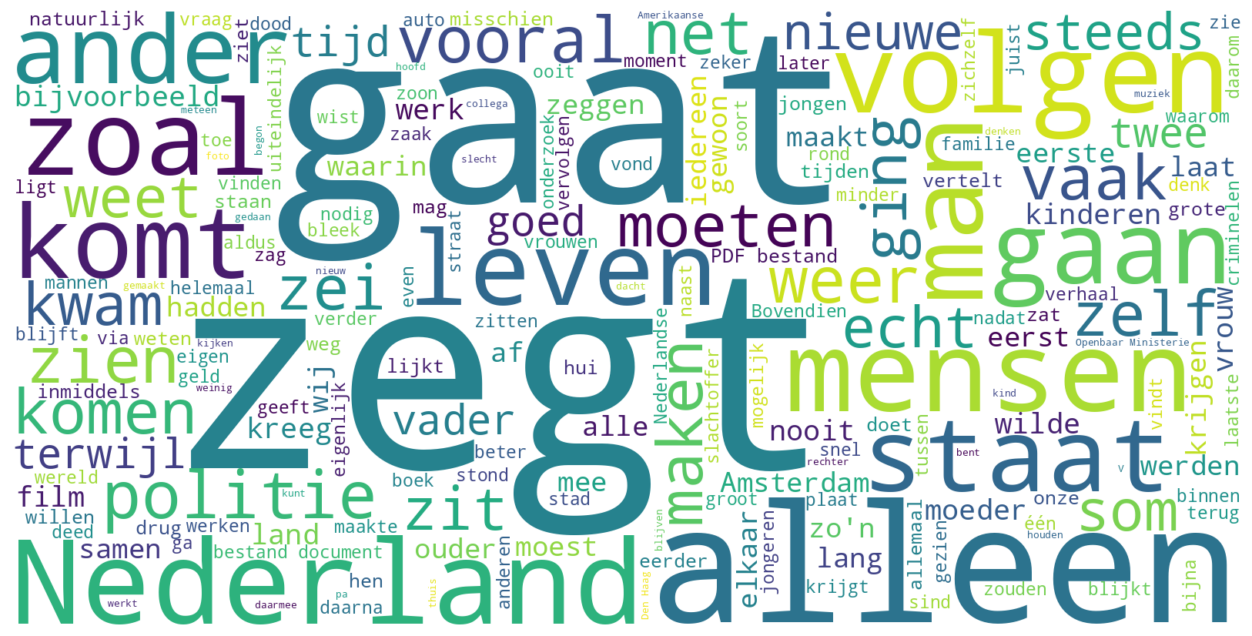

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. OPTIONAL WORDCLOUD
# ─────────────────────────────────────────────────────────────────────────────
def generate_wordcloud(df_in, save_path=None):
    from wordcloud import WordCloud
    import matplotlib.pyplot as plt
    text = " ".join(df_in["Article"].dropna().astype(str))
    wc = WordCloud(width=1600, height=800, background_color="white").generate(text)
    plt.figure(figsize=(16, 8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Wordcloud saved to {save_path}")
    else:
        plt.show()

generate_wordcloud(df, save_path="wordcloud_clean.png")